In [21]:
import os
os.chdir('/Users/ngdnh/Codespace/unifiedPPS/')

import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
%matplotlib widget

# Rabi oscillation

In [32]:
IQdata_rabi12 = np.load('./data/rabi12/duration/40_-0.1_1.0_single.pkl', allow_pickle=True)

In [39]:
real_avg_iq = [np.real(np.average(IQdata_rabi12[idx])) for idx in range(len(IQdata_rabi12))]
amplitudes = np.linspace(-0.1, 1.0, len(IQdata_rabi12))

def iq_to_prob(iq, real_avg_iq):
    # Define mapping
    IQ_min, IQ_max = min(real_avg_iq)-0.6, max(real_avg_iq)+0.6
    # Linear scaling to [0, 1]|
    p1 = (iq - IQ_min) / (IQ_max - IQ_min)
    return p1

normalized_real_avg_iq = np.array([iq_to_prob(iq, real_avg_iq) for iq in real_avg_iq])

normalized_real_avg_iq.shape

(100,)

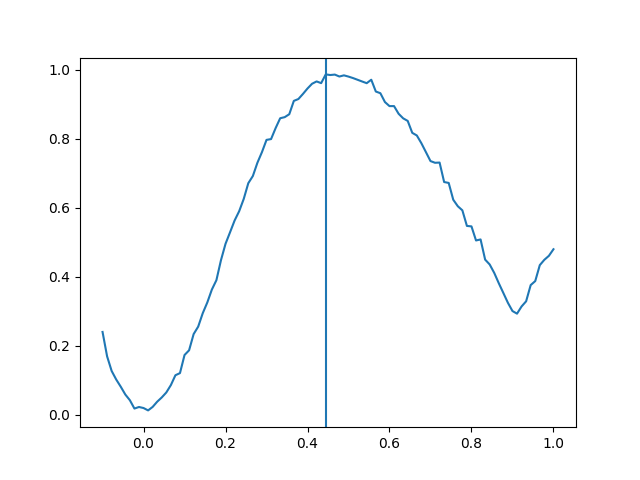

In [40]:
fig, ax = plt.subplots()

ax.plot(amplitudes, normalized_real_avg_iq)
ax.axvline(amplitudes[np.argmax(normalized_real_avg_iq)])

In [41]:
np.savez('./rabi12_active_reset_brisbane109.npz', amp_sweep=amplitudes, population_2=normalized_real_avg_iq)

In [ ]:
# Define basis states
ket0 = qt.basis(5, 0)
ket1 = qt.basis(5, 1)
ket2 = qt.basis(5, 2)
ket3 = qt.basis(5, 3)
ket4 = qt.basis(5, 4)

bra0 = ket0.dag()
bra1 = ket1.dag()
bra2 = ket2.dag()
bra3 = ket3.dag()
bra4 = ket4.dag()

# Hamiltonian builder
def Hamiltonian(lambda_0, lambda_1, lambda_2, lambda_3, delta, Delta):
    H0 = delta*ket1*bra1 + (2*delta-Delta)*ket2*bra2 + (3*delta-3*Delta)*ket3*bra3 + (4*delta-6*Delta)*ket4*bra4
    H1_dag = (lambda_0/2)*(ket1*bra0)
    H1 = (lambda_0/2)*(ket0*bra1)
    H2_dag = (lambda_1/2)*(ket2*bra1)
    H2 = (lambda_1/2)*(ket1*bra2)
    H3_dag = (lambda_2/2)*(ket3*bra2)
    H3 = (lambda_2/2)*(ket2*bra3)
    H4_dag = (lambda_3/2)*(ket4*bra3)
    H4 = (lambda_3/2)*(ket3*bra4)
    return H0, H1, H1_dag, H2, H2_dag, H3, H3_dag, H4, H4_dag

# Pulse shape function
def Omega(t, args):
    for item, pulse_specs in args.items():
        if item == 'clock':
            continue
        if t <= pulse_specs['start'] or t >= (pulse_specs['start'] + pulse_specs['tg']):
            continue
        else:
            t_local = t - pulse_specs['start']
            return pulse_specs['A'] * (np.exp(-(t_local-pulse_specs['tg']/2)**2/(2*pulse_specs['sigma']**2)) - np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) \
                        / (1-np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) # normalization part
    return 0

def qiskitOmega(t, args):
    for item, pulse_specs in args.items():
        if item == 'clock':
            continue
        if t <= pulse_specs['start'] or t >= (pulse_specs['start'] + pulse_specs['tg']):
            continue
        else:
            t_local = t - pulse_specs['start']
            f_prime = np.exp(-0.5*(t_local-pulse_specs['tg']/2)**2/pulse_specs['sigma']**2)
            f_prime_minus_one = np.exp(-0.5*(-1-pulse_specs['tg']/2)**2/pulse_specs['sigma']**2)
            return pulse_specs['A'] * (f_prime-f_prime_minus_one)/(1-f_prime_minus_one)
    return 0

# Add pulse
def add_pulse(pulse_train, pulse_name, start, tg, sigma, A):
    pulse_train[pulse_name] = {'start': start, 'tg': tg, 'sigma': sigma, 'A': A}
    pulse_train['clock'] += tg

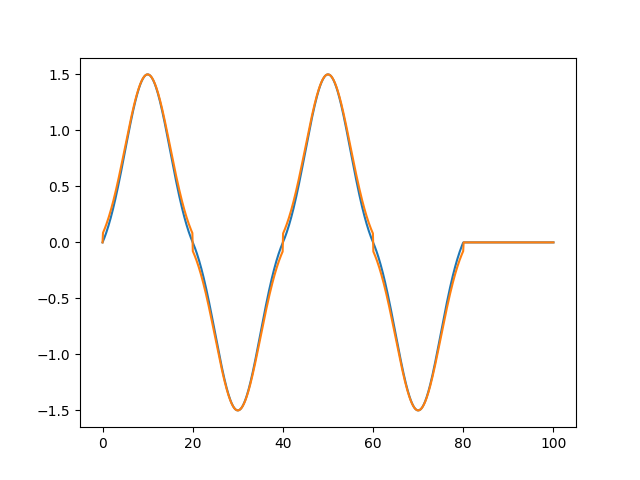

In [4]:
times = np.linspace(0, 100, 1000)

pulse_train = {'clock': 0}
add_pulse(pulse_train, 'pulse1', start=pulse_train['clock'], tg=20, sigma=5, A=1.5)
add_pulse(pulse_train, 'pulse2', start=pulse_train['clock'], tg=20, sigma=5, A=-1.5)
add_pulse(pulse_train, 'pulse3', start=pulse_train['clock'], tg=20, sigma=5, A=1.5)
add_pulse(pulse_train, 'pulse4', start=pulse_train['clock'], tg=20, sigma=5, A=-1.5)

plt.plot(times, [Omega(t, pulse_train) for t in times])
plt.plot(times, [qiskitOmega(t, pulse_train) for t in times])

In [5]:
Delta = -2*np.pi*0.3071
gamma = 0
delta = Delta - gamma * Delta

# Rabi oscillation of zero-coupling, smooth pulse (lambda_1 = 0.62)
lambda_0 = 0
lambda_1 = 0.62
lambda_2 = 0
lambda_3 = 0

# Using smooth waveform
H0, H1, H2, H3, H4 = Hamiltonian(lambda_0, lambda_1, lambda_2, lambda_3, delta, Delta)
H = [H0, [H1, lambda t, args: Omega(t, args)],
            [H2, lambda t, args: Omega(t, args)],
            [H3, lambda t, args: Omega(t, args)],
            [H4, lambda t, args: Omega(t, args)]]

pops_smooth_zerocoupling = []
for A0 in amplitudes:
    psi0 = ket1
    pulse_train = {'clock': 0}
    add_pulse(pulse_train, 'pulse1', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
    add_pulse(pulse_train, 'pulse2', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
    times = np.linspace(0, pulse_train['clock'], 100)
    options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
    result = qt.sesolve(H, psi0, times,
                        e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3, ket4*bra4],
                        args=pulse_train, options=options)
    pops_smooth_zerocoupling.append(result.expect[2][-1])  # pop of |2⟩

c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [6]:
Delta = -2*np.pi*0.3071
gamma = 0
delta = Delta - gamma * Delta

# Rabi oscillation of zero-coupling, smooth pulse (lambda_1 = 0.62)
lambda_0 = 0.52
lambda_1 = 0.62
lambda_2 = 0.72
lambda_3 = 0

# Using smooth waveform
H0, H1, H2, H3, H4 = Hamiltonian(lambda_0, lambda_1, lambda_2, lambda_3, delta, Delta)
H = [H0, [H1, lambda t, args: Omega(t, args)],
            [H2, lambda t, args: Omega(t, args)],
            [H3, lambda t, args: Omega(t, args)],
            [H4, lambda t, args: Omega(t, args)]]

pops_smooth_nonzerocoupling = []
for A0 in amplitudes:
    psi0 = ket1
    pulse_train = {'clock': 0}
    add_pulse(pulse_train, 'pulse1', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
    add_pulse(pulse_train, 'pulse2', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
    times = np.linspace(0, pulse_train['clock'], 100)
    options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
    result = qt.sesolve(H, psi0, times,
                        e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3, ket4*bra4],
                        args=pulse_train, options=options)
    pops_smooth_nonzerocoupling.append(result.expect[2][-1])  # pop of |2⟩

In [7]:
# Rabi oscillation of zero-coupling, abrupt pulse (lambda_1 = 0.595)
lambda_0 = 0
lambda_1 = 0.595
lambda_2 = 0
lambda_3 = 0

# Using abrupt waveform
H0, H1, H2, H3, H4 = Hamiltonian(lambda_0, lambda_1, lambda_2, lambda_3, delta, Delta)
H = [H0, [H1, lambda t, args: qiskitOmega(t, args)],
            [H2, lambda t, args: qiskitOmega(t, args)],
            [H3, lambda t, args: qiskitOmega(t, args)],
            [H4, lambda t, args: qiskitOmega(t, args)]]

pops_abrupt_zerocoupling = []
for A0 in amplitudes:
    psi0 = ket1
    pulse_train = {'clock': 0}
    add_pulse(pulse_train, 'pulse1', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
    add_pulse(pulse_train, 'pulse2', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
    times = np.linspace(0, pulse_train['clock'], 100)
    options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
    result = qt.sesolve(H, psi0, times,
                        e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3, ket4*bra4],
                        args=pulse_train, options=options)
    pops_abrupt_zerocoupling.append(result.expect[2][-1])  # pop of |2⟩

In [8]:
# Rabi oscillation of zero-coupling, abrupt pulse (lambda_1 = 0.595)
lambda_0 = 0.495
lambda_1 = 0.595
lambda_2 = 0.695
lambda_3 = 0

# Using abrupt waveform
H0, H1, H2, H3, H4 = Hamiltonian(lambda_0, lambda_1, lambda_2, lambda_3, delta, Delta)
H = [H0, [H1, lambda t, args: qiskitOmega(t, args)],
            [H2, lambda t, args: qiskitOmega(t, args)],
            [H3, lambda t, args: qiskitOmega(t, args)],
            [H4, lambda t, args: qiskitOmega(t, args)]]

pops_abrupt_nonzerocoupling = []
for A0 in amplitudes:
    psi0 = ket1
    pulse_train = {'clock': 0}
    add_pulse(pulse_train, 'pulse1', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
    add_pulse(pulse_train, 'pulse2', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
    times = np.linspace(0, pulse_train['clock'], 100)
    options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
    result = qt.sesolve(H, psi0, times,
                        e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3, ket4*bra4],
                        args=pulse_train, options=options)
    pops_abrupt_nonzerocoupling.append(result.expect[2][-1])  # pop of |2⟩

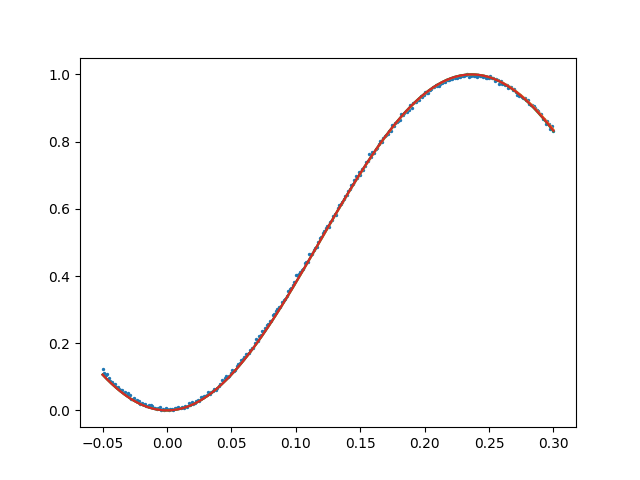

In [9]:
fig, ax = plt.subplots()

ax.scatter(amplitudes, normalized_real_avg_iq, s=2)
ax.plot(amplitudes, pops_smooth_zerocoupling)
ax.plot(amplitudes, pops_smooth_nonzerocoupling)
ax.plot(amplitudes, pops_abrupt_zerocoupling)
ax.plot(amplitudes, pops_abrupt_nonzerocoupling)
# ax.set_ylim(0.5-0.05, 0.5+0.05)
# # ax.set_xlim(0.15, 0.16)

# Fit AAE

In [16]:
uncorrected = np.load('./data/aae/aae_uncorrected.npz')
corrected_dragy = np.load('./data/aae/aae_only_dragy.npz')

In [17]:
uncorrected

NpzFile './data/aae/aae_uncorrected.npz' with keys: N, pop2

### SEsolver with Hamiltonian

In [ ]:
# Load experimental data
pop_data = uncorrected['pop2']
N_values = uncorrected['N']

# Simulation wrapper
def simulateAAE_pop_fit(lambda_0, lambda_1, lambda_2, lambda_3, gamma, A0, waveform_type):
    Delta = -2*np.pi*0.3071
    delta = Delta - gamma * Delta
    print(lambda_0, lambda_1, lambda_2, lambda_3, gamma, A0, waveform_type)

    if waveform_type == 'abrupt':
        H0, H1, H2, H3, H4 = Hamiltonian(lambda_0, lambda_1, lambda_2, lambda_3, delta, Delta)
        H = [H0, [H1, lambda t, args: qiskitOmega(t, args)],
                [H2, lambda t, args: qiskitOmega(t, args)],
                [H3, lambda t, args: qiskitOmega(t, args)],
                [H4, lambda t, args: qiskitOmega(t, args)]]
    else:
        H0, H1, H2, H3, H4 = Hamiltonian(lambda_0, lambda_1, lambda_2, lambda_3, delta, Delta)
        H = [H0, [H1, lambda t, args: Omega(t, args)],
                [H2, lambda t, args: Omega(t, args)],
                [H3, lambda t, args: Omega(t, args)],
                [H4, lambda t, args: Omega(t, args)]]
    
    pops = []
    for N in N_values:
        psi0 = ket1
        pulse_train = {'clock': 0}
        add_pulse(pulse_train, 'pulse_init', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
        counter = 0
        for i in range(N):
            add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
            counter += 1
            add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
            counter += 1
        times = np.linspace(0, pulse_train['clock'], 10000)
        options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
        result = qt.sesolve(H, psi0, times,
                            e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3, ket4*bra4],
                            args=pulse_train, options=options)
        pops.append(result.expect[2][-1])  # pop of |2⟩
    return np.array(pops)

# Loss function
def lossAAE(params):
    gamma, A0 = params
    try:
        sim_data = simulateAAE_pop_fit(gamma, A0)
        return np.mean((sim_data - pop_data)**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty

In [ ]:
# # === Optimization ===

# initial_guess = [0.009641599406739589, 0.250397620179174]
# bounds = [(0.0, 0.1), (0.0, 0.1)]

# result = minimize(lossAAE, initial_guess, bounds=bounds, method='L-BFGS-B')

# print("Optimal gamma:", result.x[0])
# print("Optimal A0:", result.x[1])
# print("Final loss:", result.fun)

(0.45, 0.55)

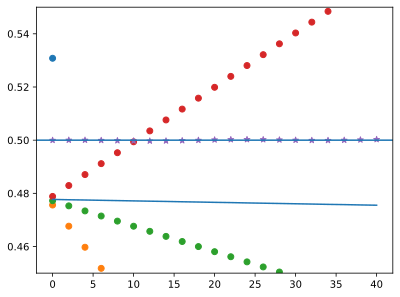

In [83]:
fig, ax = plt.subplots()

ax.axhline(0.5)
ax.scatter(N_values, pop_data)
ax.scatter(N_values, pops_sesolver)
ax.scatter(N_values, pops_sesolver_345)
ax.scatter(N_values, pops_sesolver_35)
ax.plot(N_values, pops_sesolver_finetune)
ax.scatter(N_values, pops_sesolver_finetune_deltazero, marker='*')
ax.set_ylim([0.45, 0.55])

In [ ]:
pops_sesolver_decoupled_abrupt = simulateAAE_pop_fit(lambda_0=0, lambda_1=0.595, lambda_2=0, lambda_3=0, gamma=0, A0=0.2362, waveform_type='abrupt')
pops_sesolver_coupled_abrupt = simulateAAE_pop_fit(lambda_0=0.495, lambda_1=0.595, lambda_2=0.695, lambda_3=0, gamma=0, A0=0.2362, waveform_type='abrupt')

pops_sesolver_decoupled_smooth = simulateAAE_pop_fit(lambda_0=0, lambda_1=0.62, lambda_2=0, lambda_3=0, gamma=0, A0=0.2362, waveform_type='smooth')
pops_sesolver_coupled_smooth = simulateAAE_pop_fit(lambda_0=0.52, lambda_1=0.62, lambda_2=0.72, lambda_3=0, gamma=0, A0=0.2362, waveform_type='smooth')

0 0.595 0 0 0 0.2362 abrupt


c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


0.495 0.595 0.695 0 0 0.2362 abrupt
0 0.62 0 0 0 0.2362 smooth
0.52 0.62 0.72 0 0 0.2362 smooth


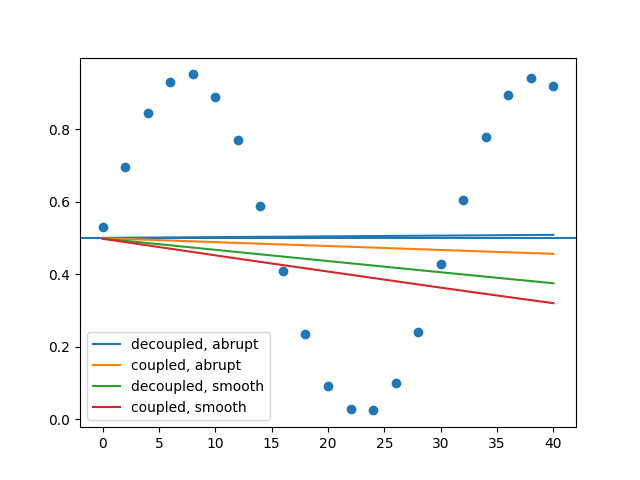

In [25]:
fig, ax = plt.subplots()

ax.axhline(0.5)
ax.scatter(N_values, pop_data)
ax.plot(N_values, pops_sesolver_decoupled_abrupt, label='decoupled, abrupt')
ax.plot(N_values, pops_sesolver_coupled_abrupt, label='coupled, abrupt')
ax.plot(N_values, pops_sesolver_decoupled_smooth, label='decoupled, smooth')
ax.plot(N_values, pops_sesolver_coupled_smooth, label='coupled, smooth')
ax.legend()

### Gate-based error model

In [14]:
def Lx01():
    return qt.Qobj(np.array([
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0]
    ]))

def Lz01():
    return qt.Qobj(np.array([
        [1, 0, 0],
        [0, -1, 0],
        [0, 0, 0]
    ]))

def Lx12():
    return qt.Qobj(np.array([
        [0, 0, 0],
        [0, 0, 1],
        [0, 1, 0]
    ]))

def Lz12():
    return qt.Qobj(np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, -1]
    ]))

def Ly12():
    return qt.Qobj(np.array([
        [0, 0, 0],
        [0, 0, -1j],
        [0, 1j, 0]
    ]))

def rot_x12(a, p):
    return (-1j*((np.pi/2+a)/2)*Lx12()-1j*(p/2)*Lz12()).expm()

def rot_x12_3(a, p, c):
    return (-1j*((np.pi/2+a)/2)*Lx12()-1j*(p/2)*Lz12()-1j*(c/2)*Ly12()).expm()

def gate_based_simulate_pop_fit(a0, p0):
    """ 
        Gate-based sim. Use only `a` (rotation) and `p` (phase) error.
    """
    
    ket0 = qt.basis(3, 0)
    ket1 = qt.basis(3, 1)
    ket2 = qt.basis(3, 2)

    pops = []
    for N in N_values:
        psi0 = ket1
        psi0 = rot_x12(a0, p0)*psi0
        for _ in range(N):
            psi0 = rot_x12(a0, p0)*rot_x12(a0, p0)*psi0
        pop2 = (np.abs(ket2.dag()*psi0))**2
        pops.append(pop2)

    return np.array(pops)

def gate_based_simulate_pop_fit_3(a0, p0, c0):
    """ 
        Gate-based sim. Use only `a` (rotation) and `p` (phase) error and `c` (axis-tilted) error.
    """
    
    ket0 = qt.basis(3, 0)
    ket1 = qt.basis(3, 1)
    ket2 = qt.basis(3, 2)

    pops = []
    for N in N_values:
        psi0 = ket1
        psi0 = rot_x12_3(a0, p0, c0)*psi0
        for _ in range(N):
            psi0 = rot_x12_3(a0, p0, c0)*rot_x12_3(a0, p0, c0)*psi0
        pop2 = (np.abs(ket2.dag()*psi0))**2
        pops.append(pop2)

    return np.array(pops)

def loss_gate_based(params):
    a0, p0 = params
    try:
        sim_data = gate_based_simulate_pop_fit(a0, p0)
        return np.mean((sim_data - pop_data)**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty
    
def loss_gate_based_3(params):
    a0, p0, c0 = params
    try:
        sim_data = gate_based_simulate_pop_fit_3(a0, p0, c0)
        return np.mean((sim_data - pop_data)**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty

In [6]:
# === Optimization ===

initial_guess = [6.28*1e-2, 3.53*1e-1]
bounds = [(0, 0.2), (0, 0.5)]

result = minimize(loss_gate_based, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", result.x[0])
print("Optimal p:", result.x[1])
print("Final loss:", result.fun)

Optimal a: 0.06303293714934308
Optimal p: 0.3530499522737237
Final loss: 0.00012656002067370963


In [7]:
pops_gatebased = gate_based_simulate_pop_fit(result.x[0], result.x[1])

pops_gatebased

array([0.52573747, 0.70826858, 0.85386185, 0.93919331, 0.95059289,
       0.88623438, 0.756428  , 0.58196865, 0.39080466, 0.2135604 ,
       0.07863033, 0.00763017, 0.01193413, 0.09085271, 0.23174319,
       0.41203497, 0.60284541, 0.77360675, 0.8969631 , 0.95315284,
       0.93317439])

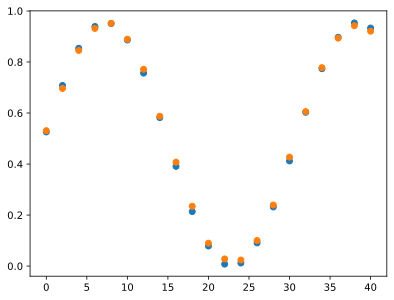

In [8]:
plt.scatter(N_values, pops_gatebased)
plt.scatter(N_values, pop_data)
# plt.scatter(N_values, uncorrected['pop2'])

In [15]:
from scipy.optimize import minimize
import numpy as np

# --- Fit 2-parameter model ---
initial_guess2 = [6.28e-2, 3.53e-1]
bounds2 = [(0, 0.2), (0, 0.5)]
result2 = minimize(loss_gate_based, initial_guess2, bounds=bounds2, method='L-BFGS-B')

a_opt, p_opt = result2.x
sim2 = gate_based_simulate_pop_fit(a_opt, p_opt)
rss2 = np.sum((pop_data - sim2)**2)
n = len(pop_data)
k2 = 2

# --- Fit 3-parameter model ---
initial_guess3 = [6.28e-2, 3.53e-1, 0.01]  # small start for c
bounds3 = [(0, 0.2), (0, 0.5), (-0.2, 0.2)]
result3 = minimize(loss_gate_based_3, initial_guess3, bounds=bounds3, method='L-BFGS-B')

a3_opt, p3_opt, c3_opt = result3.x
sim3 = gate_based_simulate_pop_fit_3(a3_opt, p3_opt, c3_opt)
rss3 = np.sum((pop_data - sim3)**2)
k3 = 3

# --- AIC function ---
def compute_aic(rss, n, k):
    return n * np.log(rss / n) + 2*k

aic2 = compute_aic(rss2, n, k2)
aic3 = compute_aic(rss3, n, k3)

delta_aic = aic3 - aic2

print("=== Results ===")
print("2-param fit: a =", a_opt, " p =", p_opt)
print("   RSS =", rss2, " AIC =", aic2)
print("3-param fit: a =", a3_opt, " p =", p3_opt, " c =", c3_opt)
print("   RSS =", rss3, " AIC =", aic3)
print("ΔAIC (3 - 2) =", delta_aic)

# Rule of thumb interpretation
if delta_aic < -10:
    print("=> Very strong evidence in favor of the 3-param model")
elif delta_aic < -4:
    print("=> Strong evidence in favor of the 3-param model")
elif delta_aic < -2:
    print("=> Moderate evidence in favor of the 3-param model")
elif delta_aic < 2:
    print("=> Models are essentially indistinguishable")
else:
    print("=> 2-param model strongly preferred (adding c not justified)")

=== Results ===
2-param fit: a = 0.06303293714934306  p = 0.3530499522737237
   RSS = 0.0026577604341479024  AIC = -184.47067170247166
3-param fit: a = 0.06300315316680372  p = 0.3530453333959009  c = 0.010001244212624369
   RSS = 0.0026577640157592203  AIC = -182.47064340278516
ΔAIC (3 - 2) = 2.0000282996865053
=> 2-param model strongly preferred (adding c not justified)


In [10]:
rss2

0.0026577604341479024

In [216]:
np.savez('./data/aae/aae_only_dragy_fit.npz', N=N_values, pop2=pops_gatebased)

In [99]:
np.savez('./data/aae/aae_sim_gatebased.npz', N=N_values, pop2=pops_gatebased)

In [88]:
pops_gatebased_only_amplitude = gate_based_simulate_pop_fit(result.x[0]+0.025, 0)

pops_gatebased_only_amplitude

array([5.43891230e-01, 7.12733543e-01, 8.55549587e-01, 9.54866946e-01,
       9.98534926e-01, 9.81211094e-01, 9.05014884e-01, 7.79268301e-01,
       6.19355447e-01, 4.44840396e-01, 2.77073687e-01, 1.36580252e-01,
       4.05483542e-02, 7.26737155e-04, 2.19872617e-02, 1.01728870e-01,
       2.30195807e-01, 3.91671157e-01, 5.66399685e-01, 7.33004736e-01,
       8.71103497e-01])

In [100]:
np.savez('./data/aae/aae_sim_gatebased_onlyepsilon.npz', N=N_values, pop2=pops_gatebased_only_amplitude)

# Fit APE

In [26]:
ape_data = np.load('./data/ape/ape_data.npz')
angle_swept = ape_data['angle_swept']
ape_pops = ape_data['pe_pops']

ape_data

NpzFile './data/ape/ape_data.npz' with keys: angle_swept, pe_pops

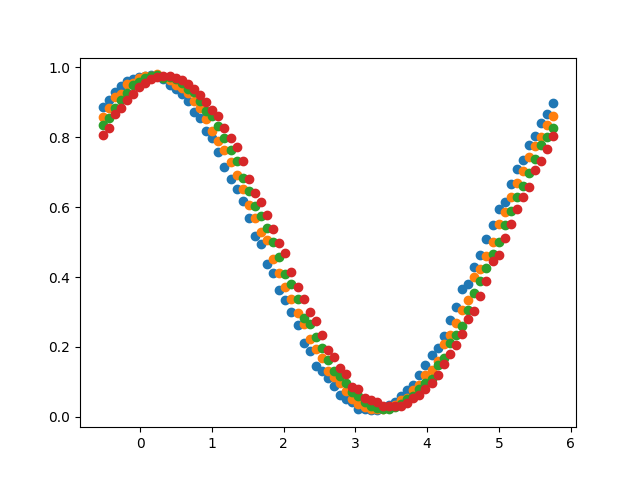

In [42]:
fig, ax = plt.subplots()

ax.scatter(angle_swept, ape_pops[0][:, 0])
ax.scatter(angle_swept, ape_pops[1][:, 0])
ax.scatter(angle_swept, ape_pops[2][:, 0])
ax.scatter(angle_swept, ape_pops[3][:, 0])

In [134]:
# Simulation wrapper
def simulateAPE_pop_fit(lambda_0, lambda_1, lambda_2, lambda_3, gamma, A0, waveform_type):
    Delta = -2*np.pi*0.3071
    delta = Delta - gamma * Delta
    print(lambda_0, lambda_1, lambda_2, lambda_3, gamma, A0, waveform_type)

    if waveform_type == 'abrupt':
        H0, H1, H2, H3, H4 = Hamiltonian(lambda_0, lambda_1, lambda_2, lambda_3, delta, Delta)
        H = [H0, [H1, lambda t, args: qiskitOmega(t, args)],
                [H2, lambda t, args: qiskitOmega(t, args)],
                [H3, lambda t, args: qiskitOmega(t, args)],
                [H4, lambda t, args: qiskitOmega(t, args)]]
    else:
        H0, H1, H1_dag, H2, H2_dag, H3, H3_dag, H4, H4_dag = Hamiltonian(lambda_0, lambda_1, lambda_2, lambda_3, delta, Delta)
        H = [H0, [H1, lambda t, args: np.conjugate(Omega(t, args))], [H1_dag, lambda t, args: (Omega(t, args))],
                [H2, lambda t, args: np.conjugate(Omega(t, args))], [H2_dag, lambda t, args: (Omega(t, args))],
                [H3, lambda t, args: np.conjugate(Omega(t, args))], [H3_dag, lambda t, args: (Omega(t, args))],
                [H4, lambda t, args: np.conjugate(Omega(t, args))], [H4_dag, lambda t, args: (Omega(t, args))]]
    
    pops = []
    rep_range = [1, 3, 5, 7]
    for rep in rep_range:
        pops_versus_angles = []
        for phi in angle_swept:
            A0_phi = A0*np.exp(1j*phi)
            psi0 = 1j*ket1
            pulse_train = {'clock': 0}
            add_pulse(pulse_train, 'pulse_init', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
            counter = 0
            for r in range(rep):
                add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=A0)
                counter += 1
                add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=-A0)
                counter += 1
            add_pulse(pulse_train, 'map_phase_to_pop', start=pulse_train['clock'], tg=20, sigma=5, A=-A0_phi)
            times = np.linspace(0, pulse_train['clock'], 1000)
            options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
            result = qt.sesolve(H, psi0, times,
                                e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3, ket4*bra4],
                                args=pulse_train, options=options)
            pops_versus_angles.append(result.expect[2][-1])  # pop of |2⟩
        pops.append(pops_versus_angles)
    return np.array(pops)

c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


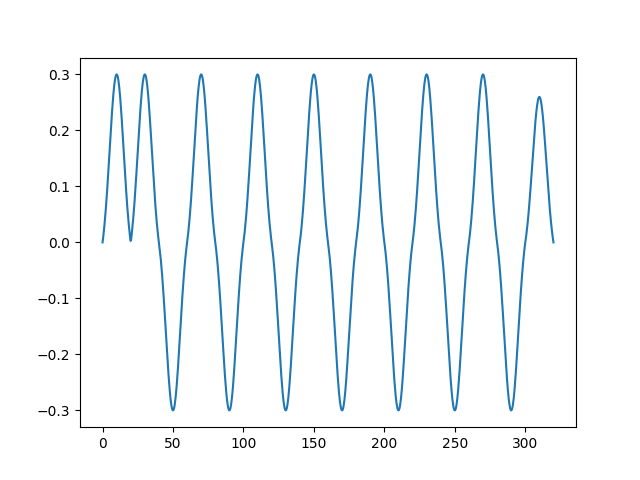

In [100]:
fig, ax = plt.subplots()

ax.plot(times, [Omega(t, args=pulse_train) for t in times])

In [135]:
# popsAPE_sesolver_decoupled_abrupt = simulateAPE_pop_fit(lambda_0=0, lambda_1=0.595, lambda_2=0, lambda_3=0, gamma=0, A0=0.24, waveform_type='abrupt')
# popsAPE_sesolver_coupled_abrupt = simulateAPE_pop_fit(lambda_0=0.495, lambda_1=0.595, lambda_2=0.695, lambda_3=0, gamma=-0.001, A0=0.25, waveform_type='abrupt')

# popsAPE_sesolver_decoupled_smooth = simulateAPE_pop_fit(lambda_0=0, lambda_1=0.62, lambda_2=0, lambda_3=0, gamma=0, A0=0.24, waveform_type='smooth')
popsAPE_sesolver_coupled_smooth = simulateAPE_pop_fit(lambda_0=0.52, lambda_1=0.62, lambda_2=0.72, lambda_3=0.82, gamma=-0.001, A0=0.25, waveform_type='smooth')

0.52 0.62 0.72 0.82 -0.001 0.25 smooth


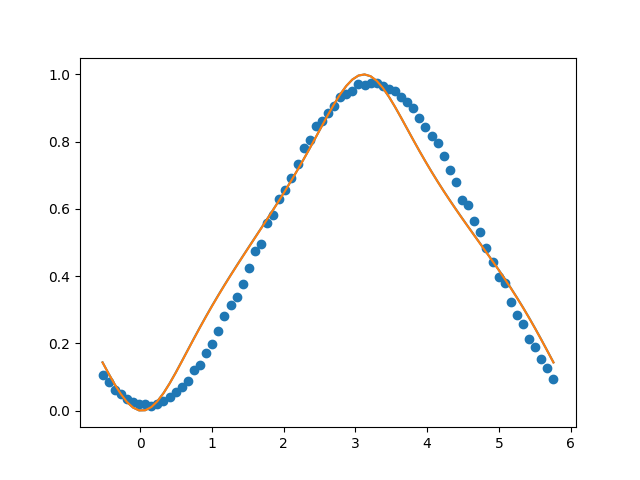

In [59]:
fig, ax = plt.subplots()

ax.scatter(angle_swept, ape_pops[0][:, 2])
# ax.scatter(angle_swept, ape_pops[1][:, 2])
# ax.scatter(angle_swept, ape_pops[2][:, 2])
# ax.scatter(angle_swept, ape_pops[3][:, 2])

ax.plot(angle_swept, popsAPE_sesolver_coupled_abrupt[0])
# ax.plot(angle_swept, popsAPE_sesolver_coupled_abrupt[1])
# ax.plot(angle_swept, popsAPE_sesolver_coupled_abrupt[2])
# ax.plot(angle_swept, popsAPE_sesolver_coupled_abrupt[3])

ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[0])
# ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[1])
# ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[2])
# ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[3])

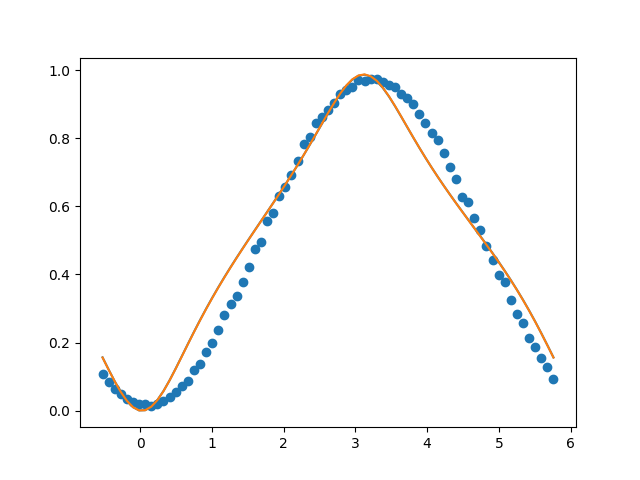

In [67]:
fig, ax = plt.subplots()

ax.scatter(angle_swept, ape_pops[0][:, 2])
# ax.scatter(angle_swept, ape_pops[1][:, 2])
# ax.scatter(angle_swept, ape_pops[2][:, 2])
# ax.scatter(angle_swept, ape_pops[3][:, 2])

ax.plot(angle_swept, popsAPE_sesolver_coupled_abrupt[0])
# ax.plot(angle_swept, popsAPE_sesolver_coupled_abrupt[1])|
# ax.plot(angle_swept, popsAPE_sesolver_coupled_abrupt[2])
# ax.plot(angle_swept, popsAPE_sesolver_coupled_abrupt[3])

ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[0])
# ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[1])
# ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[2])
# ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[3])

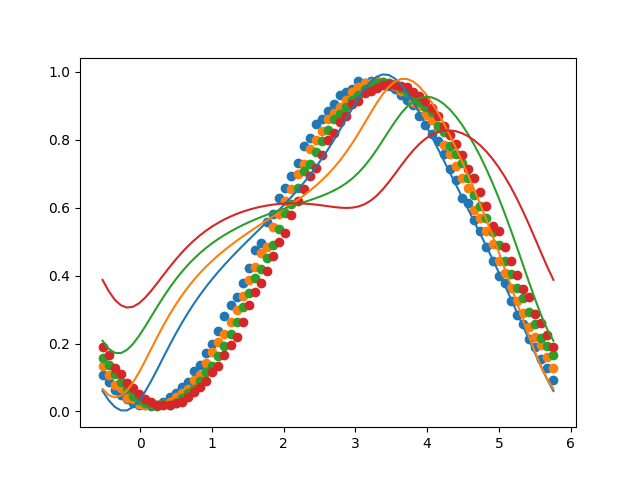

In [75]:
fig, ax = plt.subplots()

ax.scatter(angle_swept, ape_pops[0][:, 2])
ax.scatter(angle_swept, ape_pops[1][:, 2])
ax.scatter(angle_swept, ape_pops[2][:, 2])
ax.scatter(angle_swept, ape_pops[3][:, 2])

ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[0])
ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[1])
ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[2])
ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[3])

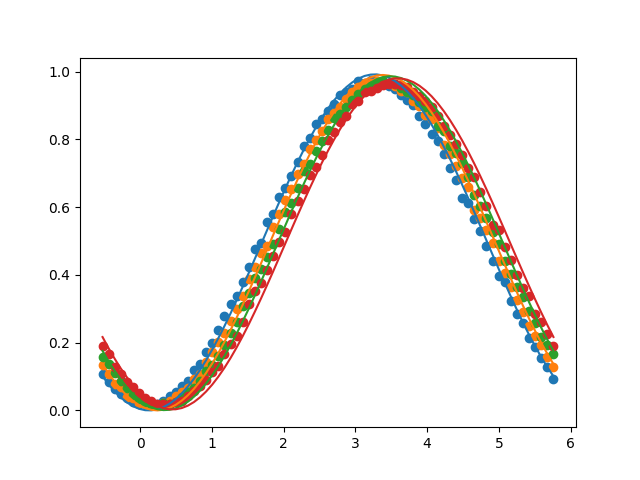

In [136]:
fig, ax = plt.subplots()

ax.scatter(angle_swept, ape_pops[0][:, 2])
ax.scatter(angle_swept, ape_pops[1][:, 2])
ax.scatter(angle_swept, ape_pops[2][:, 2])
ax.scatter(angle_swept, ape_pops[3][:, 2])

ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[0])
ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[1])
ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[2])
ax.plot(angle_swept, popsAPE_sesolver_coupled_smooth[3])